In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

<h1 style="color:blue;">STEP 1:CREATE SAMPLE DATASET</h1>

In [4]:
data = {
    "area": [
        800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700,
        1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700,
        2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3800
    ],

    "bedrooms": [
        2, 2, 2, 3, 3, 3, 3, 3, 4, 4,
        4, 4, 4, 4, 4, 5, 5, 5, 5, 5,
        5, 5, 6, 6, 6, 6, 6, 6, 7, 7
    ],

    "bathrooms": [
        1, 2, 2, 2, 2, 2, 3, 3, 3, 3,
        3, 3, 4, 4, 4, 4, 4, 4, 5, 5,
        5, 5, 5, 5, 6, 6, 6, 6, 7, 7
    ],

    "age": [
        18, 16, 15, 14, 13, 12, 11, 10, 9, 9,
        8, 8, 7, 7, 6, 6, 5, 5, 4, 4,
        3, 3, 2, 2, 2, 1, 1, 1, 1, 1
    ],

    "location_score": [
        5, 5, 6, 6, 6, 7, 7, 7, 8, 8,
        8, 8, 9, 9, 9, 9, 9, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10
    ],

    "price": [
        2500000, 2800000, 3200000, 3600000, 4100000,
        4500000, 5000000, 5600000, 6200000, 6800000,
        7300000, 7900000, 8500000, 9100000, 9800000,
        10500000, 11200000, 12000000, 12800000, 13600000,
        14500000, 15300000, 16200000, 17100000, 18000000,
        19000000, 20000000, 21200000, 22500000, 24000000
    ]
}

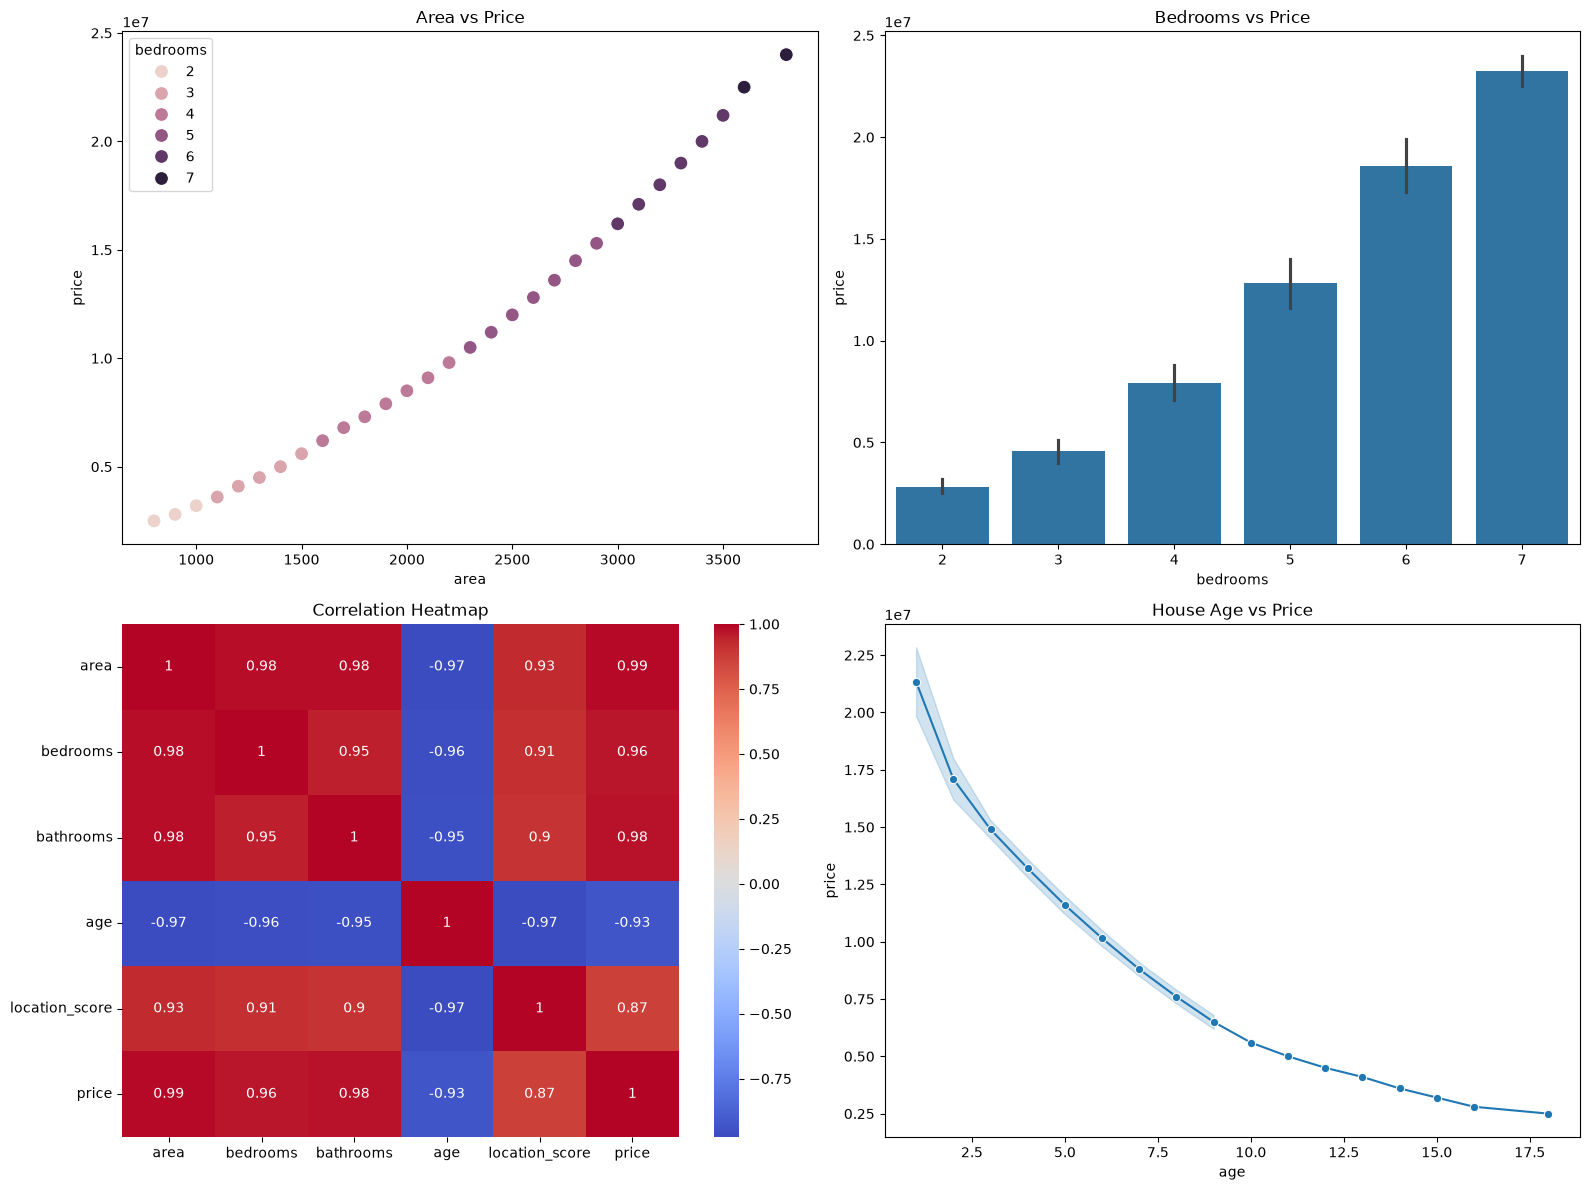

In [5]:

df = pd.DataFrame(data)

# Graphs
plt.figure(figsize=(16,12))

# 1. Area vs Price
plt.subplot(2,2,1)
sns.scatterplot(data=df, x="area", y="price", hue="bedrooms", s=100)
plt.title("Area vs Price")

# 2. Bedrooms vs Average Price
plt.subplot(2,2,2)
sns.barplot(data=df, x="bedrooms", y="price")
plt.title("Bedrooms vs Price")

# 3. Correlation Heatmap
plt.subplot(2,2,3)
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

# 4. Age vs Price
plt.subplot(2,2,4)
sns.lineplot(data=df, x="age", y="price", marker="o")
plt.title("House Age vs Price")

plt.tight_layout()
plt.show()

In [6]:
df = pd.DataFrame(data)

print("DATASET PREVIEW: \n")
print(df.head())


DATASET PREVIEW: 

   area  bedrooms  bathrooms  age  location_score    price
0   800         2          1   18               5  2500000
1   900         2          2   16               5  2800000
2  1000         2          2   15               6  3200000
3  1100         3          2   14               6  3600000
4  1200         3          2   13               6  4100000


<h1 style="color:blue;">STEP 2: Define Input (X) and Output (Y)</h1>

In [7]:
X = df[["area","bedrooms","bathrooms","age","location_score"]]
Y = df[["price"]]
print(X)

    area  bedrooms  bathrooms  age  location_score
0    800         2          1   18               5
1    900         2          2   16               5
2   1000         2          2   15               6
3   1100         3          2   14               6
4   1200         3          2   13               6
5   1300         3          2   12               7
6   1400         3          3   11               7
7   1500         3          3   10               7
8   1600         4          3    9               8
9   1700         4          3    9               8
10  1800         4          3    8               8
11  1900         4          3    8               8
12  2000         4          4    7               9
13  2100         4          4    7               9
14  2200         4          4    6               9
15  2300         5          4    6               9
16  2400         5          4    5               9
17  2500         5          4    5              10
18  2600         5          5  

<h1 style="color:blue;">STEP 3: Split Data into Training and Testing </h1>

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)
print(X_train)

    area  bedrooms  bathrooms  age  location_score
28  3600         7          7    1              10
24  3200         6          6    2              10
12  2000         4          4    7               9
0    800         2          1   18               5
4   1200         3          2   13               6
16  2400         5          4    5               9
5   1300         3          2   12               7
13  2100         4          4    7               9
11  1900         4          3    8               8
22  3000         6          5    2              10
1    900         2          2   16               5
2   1000         2          2   15               6
25  3300         6          6    1              10
3   1100         3          2   14               6
21  2900         5          5    3              10
26  3400         6          6    1              10
18  2600         5          5    4              10
29  3800         7          7    1              10
20  2800         5          5  

<h1 style="color:blue;">STEP 4: Train Machine Learning Model</h1>

In [9]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 5)","[[ 9794.3 , 108545.09, 314079.29, 403987.49,-659174.43]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['area','bedrooms','bathrooms','age','location_score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-9814607.69]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


<h1 style="color:blue;">STEP 5:ACCURACY </h1>

In [10]:
score = model.score(X_test,Y_test)
print("\nMODEL PERFORMANCE :", round(score*100,2),"%")


MODEL PERFORMANCE : 99.51 %


<h1 style="color:green;">STEP 6:PREDICT NEW HOUSE PRICE</h1>

In [11]:
#EXAMPLE
#---

#area = 1400
#bedrooms = 3
#bathrooms=2
#age=4
#location_score = 8
#------

In [12]:
new_house =[[1600,3,2,4,8]]
predict_price = model.predict(new_house)
print("\n PREDICT HOUSE PRICE :")
print("Rs", round(predict_price[0][0],2),"lakh")


 PREDICT HOUSE PRICE :
Rs 3152621.46 lakh
